#THE EDA

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore') 
import gc

In [ ]:
file = pd.read_csv('heart.csv')
file1=pd.read_csv('heart.csv')

In [ ]:
file.head
file=file1

In [ ]:
file.info()
 


In [ ]:
file.drop_duplicates()


In [ ]:
def plot(var,num):
  plt.subplot(2,2,num)
  sns.histplot(file[var],kde=True)
  plt.tight_layout()
plot('Age',1)
plot('RestingBP',2)
plot('Cholesterol',3)
plot('MaxHR',4)

In [ ]:
new_mean=file.loc[file['Cholesterol'] != 0,'Cholesterol'].mean()
print(round(new_mean,2))

In [ ]:
file["Cholesterol"]=file["Cholesterol"].replace(0,244.64)

In [ ]:
file['RestingBP'] = file['RestingBP'].astype(float)
file.loc[file['RestingBP'] == 0,'RestingBP']=round(file.loc[file['RestingBP'] != 0,'RestingBP'].mean(),2)


#preprocessing


In [ ]:
file['Cholesterol'].value_counts()


In [ ]:
file['MaxHR'].value_counts()

In [ ]:
file['RestingBP'].value_counts()

In [ ]:
file['Age'].value_counts()

In [ ]:
file['ChestPainType_TA'].value_counts()

In [ ]:
file['Sex'].value_counts()

In [164]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   ChestPainType_ATA  918 non-null    int64  
 8   ChestPainType_NAP  918 non-null    int64  
 9   ChestPainType_TA   918 non-null    int64  
 10  ExerciseAngina_Y   918 non-null    int64  
 11  RestingECG_Normal  918 non-null    int64  
 12  RestingECG_ST      918 non-null    int64  
 13  ST_Slope_Flat      918 non-null    int64  
 14  ST_Slope_Up        918 non-null    int64  
 15  Sex_M              918 non-null    int64  
dtypes: float64(1), int64(15)
memory usage

In [ ]:
file['Sex'] =file['Sex'].map({'M':0,'F':1})

In [ ]:
file =pd.get_dummies(file,columns=['ChestPainType'],drop_first=True,dtype=int)

In [ ]:
file['ST_Slope'].value_counts()

In [ ]:
file=pd.get_dummies(file,columns=['ExerciseAngina'],drop_first=True,dtype=int)

In [ ]:
file=pd.get_dummies(file,columns=['RestingECG'],drop_first=True,dtype=int)

In [ ]:
file['RestingECG'].value_counts()

In [161]:
file.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_Y,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Sex_M
0,40,140,289,0,172,0.0,0,1,0,0,0,1,0,0,1,1
1,49,160,180,0,156,1.0,1,0,1,0,0,1,0,1,0,0
2,37,130,283,0,98,0.0,0,1,0,0,0,0,1,0,1,1
3,48,138,214,0,108,1.5,1,0,0,0,1,1,0,1,0,0
4,54,150,195,0,122,0.0,0,0,1,0,0,1,0,0,1,1


In [ ]:
file['ST_Slope_Up'].astype(int)

In [ ]:
del file['ChestPainType_NAP']

In [152]:
file=pd.get_dummies(file,columns=['ST_Slope'],drop_first=True,dtype=int)

In [153]:
file=pd.get_dummies(file,columns=['Sex'],drop_first=True,dtype=int)

In [ ]:
file['Oldpeak'].value_counts()

In [156]:
del file1
gc.collect()

80379

In [159]:
file=file.astype({
  'Cholesterol':int,
  'RestingBP':int
})

In [ ]:
from scipy.stats import chi2_contingency
alpha = 0.10
features = [
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'ExerciseAngina_Y',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ST_Slope_Flat',
    'ST_Slope_Up',
    'Sex_M'
]
results={}
for i in features:
 contigency_tab = pd.crosstab(file[i],file['HeartDisease'])
 chi2_stat,p_val,df,expected=chi2_contingency(contigency_tab)
 decision = "keep feature(null hypothses rejected)"if p_val<alpha else "discard feature (null hypothesis acepted)"
 results[i]={
  'chi2_stats':chi2_stat,
  'p_val':p_val,
  'degree of freedom':df,
  'epected':expected,
  'descision':decision
 }
results=pd.DataFrame(results)
print(results)

In [ ]:
cleaned = file[['age', 'Age',

    'RestingBP',

    'Cholesterol',

    'FastingBS',

    'MaxHR',

    'Oldpeak',

    'HeartDisease',
                'ChestPainType_ATA',
                'ChestPainType_NAP',
                'ExerciseAngina_Y',
                'RestingECG_Normal',
                'RestingECG_ST',
                'ST_Slope_Flat',
                'ST_Slope_Up',
                'Sex_M', ]]

In [ ]:
from scipy.stats import pearsonr
olm= [ 'Age',

    'RestingBP',

    'Cholesterol',

    'FastingBS',

    'MaxHR',

    'Oldpeak'

    ]
coorelation = {
  feature:pearsonr(file[feature],file['HeartDisease'])[0]
  for feature in olm
}


{'Age': np.float64(0.28203850581899725), 'RestingBP': np.float64(0.11790857244927677), 'Cholesterol': np.float64(0.09258582507897906), 'FastingBS': np.float64(0.26729118611029823), 'MaxHR': np.float64(-0.4004207694631902), 'Oldpeak': np.float64(0.4039507220628865)}


In [ ]:
coorelation=pd.DataFrame(list(coorelation.items()),columns=['feature','coorelation'])

In [180]:
print(coorelation)

       feature  coorelation
0          Age     0.282039
1    RestingBP     0.117909
2  Cholesterol     0.092586
3    FastingBS     0.267291
4        MaxHR    -0.400421
5      Oldpeak     0.403951


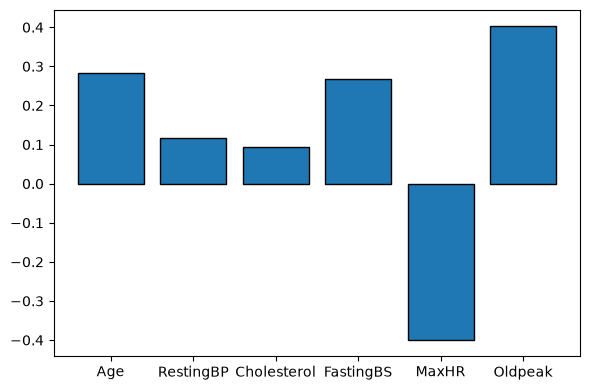

In [186]:
plt.figure(figsize=(6,4))
plt.bar(coorelation['feature'],coorelation['coorelation'],edgecolor='black')
plt.tight_layout()